Installing and importing libs

In [1]:
!pip install faker --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.9 MB/s eta 0:00:00


In [2]:
import json, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from faker import Faker
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

fake = Faker()
random.seed(42)
np.random.seed(42)
print("Libraries loaded")

Libraries loaded


Synthetic Data Generation (WITH OUTLIERS)
KEY FIX vs your uniform data:
  - 70% normal users  → low buffering, low latency
  - 20% binge users   → long sessions, occasional buffering
  - 10% bad sessions  → HIGH buffering, HIGH latency, errors
This creates the outliers you were missing.

In [3]:
DEVICES      = ["mobile", "web", "smart_tv", "tablet"]
RESOLUTIONS  = ["480p", "720p", "1080p", "4K"]
ACTIONS      = ["play", "pause", "seek", "stop"]
CDNS         = ["Akamai", "CloudFront", "OpenConnect"]
REGIONS      = ["us-east", "us-west", "eu-west", "ap-south", "ap-southeast"]
ERRORS       = [None, None, None, None, None,          # 5x None = mostly no error
                "network_failure", "crash", "timeout"]

def make_session(session_type):
    """Returns one log record. session_type drives the distribution."""

    if session_type == "normal":
        buffering_ms = max(0, int(np.random.normal(300, 100)))    # avg 300ms
        latency_ms   = max(0, int(np.random.normal(80,  20)))     # avg 80ms
        watch_sec    = int(np.random.normal(1800, 600))           # ~30 min
        error        = random.choices(ERRORS, weights=[10,10,10,10,10,1,1,1])[0]

    elif session_type == "binge":
        buffering_ms = max(0, int(np.random.normal(500, 200)))    # slightly worse
        latency_ms   = max(0, int(np.random.normal(100, 30)))
        watch_sec    = int(np.random.normal(7200, 1200))          # ~2 hrs
        error        = random.choices(ERRORS, weights=[10,10,10,10,10,2,2,1])[0]

    else:  # "bad" — THIS creates your outliers
        buffering_ms = max(0, int(np.random.normal(4000, 1500)))  # HIGH buffering
        latency_ms   = max(0, int(np.random.normal(400,  150)))   # HIGH latency
        watch_sec    = int(np.random.normal(300, 200))            # short — they gave up
        error        = random.choices(ERRORS, weights=[2,2,2,2,2,4,4,4])[0]

    return {
        "user_id"       : fake.uuid4()[:8],
        "session_id"    : fake.uuid4()[:12],
        "timestamp"     : (datetime(2026, 1, 1) + timedelta(seconds=random.randint(0, 86400*90))).isoformat(),
        "device"        : random.choice(DEVICES),
        "resolution"    : random.choice(RESOLUTIONS),
        "action"        : random.choice(ACTIONS),
        "buffering_ms"  : buffering_ms,
        "latency_ms"    : latency_ms,
        "watch_time_sec": max(0, watch_sec),
        "error"         : error,
        "cdn"           : random.choice(CDNS),
        "region"        : random.choice(REGIONS),
        "status"        : "failed" if error else "success",
        "session_type"  : session_type   # keep for validation
    }

# 70% normal, 20% binge, 10% bad
N = 50000
types = (["normal"] * int(N * 0.70) +
         ["binge"]  * int(N * 0.20) +
         ["bad"]    * int(N * 0.10))
random.shuffle(types)

logs = [make_session(t) for t in types]

with open("netflix_logs_50k.json", "w") as f:
    json.dump(logs, f)

print(f"✅ Generated {len(logs):,} logs  →  netflix_logs_50k.json")


✅ Generated 50,000 logs  →  netflix_logs_50k.json


Loading into Data Frames

In [4]:
with open("netflix_logs_50k.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df.shape)
print(df.dtypes)
df.head(3)

(50000, 14)
user_id                   object
session_id                object
timestamp         datetime64[ns]
device                    object
resolution                object
action                    object
buffering_ms               int64
latency_ms                 int64
watch_time_sec             int64
error                     object
cdn                       object
region                    object
status                    object
session_type              object
dtype: object


,user_id,session_id,timestamp,device,resolution,action,buffering_ms,latency_ms,watch_time_sec,error,cdn,region,status,session_type
0,61d76a0c,0f01dcaa-452,2026-01-07 04:16:32,smart_tv,4K,stop,349,77,2188,None,Akamai,us-east,success,normal
1,a5295d1d,215b2cd1-436,2026-02-08 05:46:24,web,4K,pause,804,92,6919,None,OpenConnect,us-east,success,binge
2,5fef67fa,b8530f80-a44,2026-01-06 05:24:08,smart_tv,480p,stop,457,95,1518,None,CloudFront,us-east,success,normal


Buffering Analysis

In [5]:
df["buffer_issue"] = df["buffering_ms"].apply(
    lambda x: "High Buffering" if x > 2000 else "Normal"
)

print(df["buffer_issue"].value_counts())
print(f"\nAvg buffering (Normal): {df[df.buffer_issue=='Normal']['buffering_ms'].mean():.0f} ms")
print(f"Avg buffering (High):   {df[df.buffer_issue=='High Buffering']['buffering_ms'].mean():.0f} ms")

buffer_issue
Normal            45483
High Buffering     4517
Name: count, dtype: int64

Avg buffering (Normal): 354 ms
Avg buffering (High):   4259 ms


Network Quality Detection

In [6]:
df["network_issue"] = df["latency_ms"].apply(
    lambda x: "Low Quality" if x > 150 else "Good"
)

print(df["network_issue"].value_counts())

network_issue
Good           44798
Low Quality     5202
Name: count, dtype: int64


Error Detection

In [7]:
df["error_issue"] = df["error"].apply(
    lambda x: "Playback Failure" if pd.notna(x) and x is not None else "No Error"
)

error_rate = (df["error_issue"] == "Playback Failure").mean() * 100
print(df["error_issue"].value_counts())
print(f"\nError rate: {error_rate:.2f}%")

error_issue
No Error            44371
Playback Failure     5629
Name: count, dtype: int64

Error rate: 11.26%


CDN + Region Analysis

In [8]:
print("── Avg Buffering by CDN ──")
print(df.groupby("cdn")["buffering_ms"].mean().sort_values(ascending=False).round(1))

print("\n── Avg Latency by Region ──")
print(df.groupby("region")["latency_ms"].mean().sort_values(ascending=False).round(1))

── Avg Buffering by CDN ──
cdn
CloudFront     713.7
Akamai         710.8
OpenConnect    696.2
Name: buffering_ms, dtype: float64

── Avg Latency by Region ──
region
eu-west         116.0
us-east         115.3
us-west         115.1
ap-south        114.9
ap-southeast    114.5
Name: latency_ms, dtype: float64


Decision Engine

In [9]:
def decide_action(row):
    if row["buffering_ms"] > 2000:
        return "Reduce Bitrate"
    elif row["error_issue"] == "Playback Failure":
        return "Switch CDN"
    elif row["latency_ms"] > 150:
        return "Adjust Quality"
    else:
        return "No Action"

df["action_taken"] = df.apply(decide_action, axis=1)

print(df["action_taken"].value_counts())

action_taken
No Action         41733
Reduce Bitrate     4517
Switch CDN         3156
Adjust Quality      594
Name: count, dtype: int64


Aggregated Insights

In [10]:
avg_buffer    = df["buffering_ms"].mean()
avg_watch     = df["watch_time_sec"].mean() / 60
error_rate    = (df["error_issue"] == "Playback Failure").mean() * 100
high_buf_rate = (df["buffer_issue"] == "High Buffering").mean() * 100

print(f"Avg Buffering      : {avg_buffer:.0f} ms")
print(f"Avg Watch Time     : {avg_watch:.1f} min")
print(f"Error Rate         : {error_rate:.2f}%")
print(f"High Buffering Rate: {high_buf_rate:.2f}%")

Avg Buffering      : 707 ms
Avg Watch Time     : 45.6 min
Error Rate         : 11.26%
High Buffering Rate: 9.03%


Visualizations

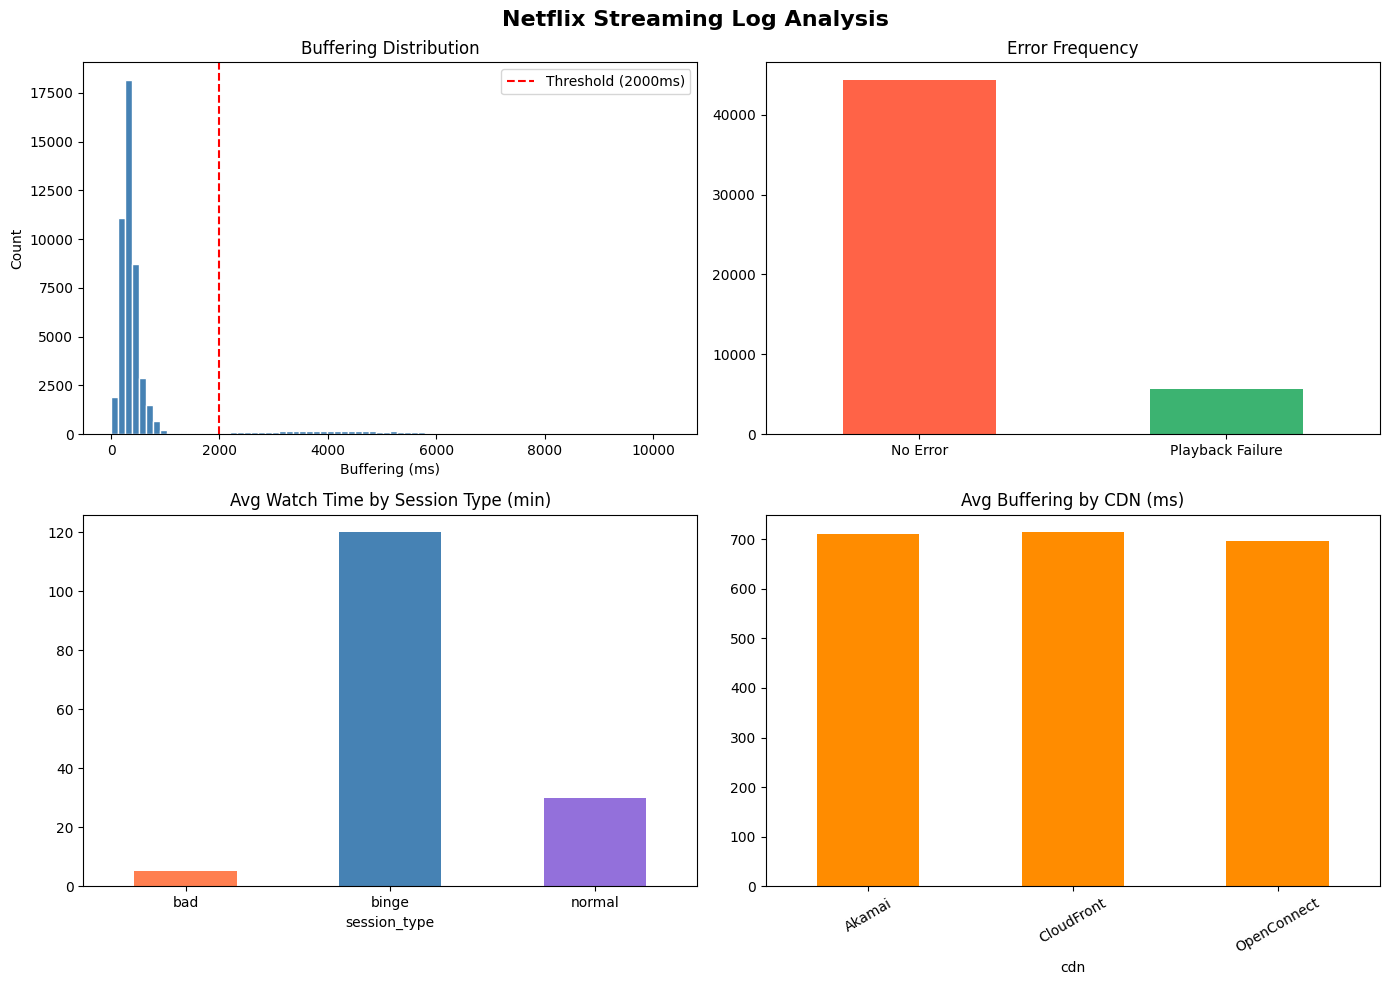

 Charts saved


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Netflix Streaming Log Analysis", fontsize=16, fontweight="bold")

# Chart 1: Buffering distribution (log scale to show outliers clearly)
axes[0, 0].hist(df["buffering_ms"], bins=80, color="steelblue", edgecolor="white")
axes[0, 0].axvline(2000, color="red", linestyle="--", label="Threshold (2000ms)")
axes[0, 0].set_title("Buffering Distribution")
axes[0, 0].set_xlabel("Buffering (ms)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# Chart 2: Error frequency
df["error_issue"].value_counts().plot(kind="bar", ax=axes[0, 1], color=["tomato", "mediumseagreen"])
axes[0, 1].set_title("Error Frequency")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=0)

# Chart 3: Watch time by session type
df.groupby("session_type")["watch_time_sec"].mean().div(60).plot(
    kind="bar", ax=axes[1, 0], color=["coral", "steelblue", "mediumpurple"]
)
axes[1, 0].set_title("Avg Watch Time by Session Type (min)")
axes[1, 0].tick_params(axis="x", rotation=0)

# Chart 4: Avg buffering per CDN
df.groupby("cdn")["buffering_ms"].mean().plot(
    kind="bar", ax=axes[1, 1], color="darkorange"
)
axes[1, 1].set_title("Avg Buffering by CDN (ms)")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("analysis_charts.png", dpi=150)
plt.show()
print(" Charts saved")



Clustering- K means + PCA

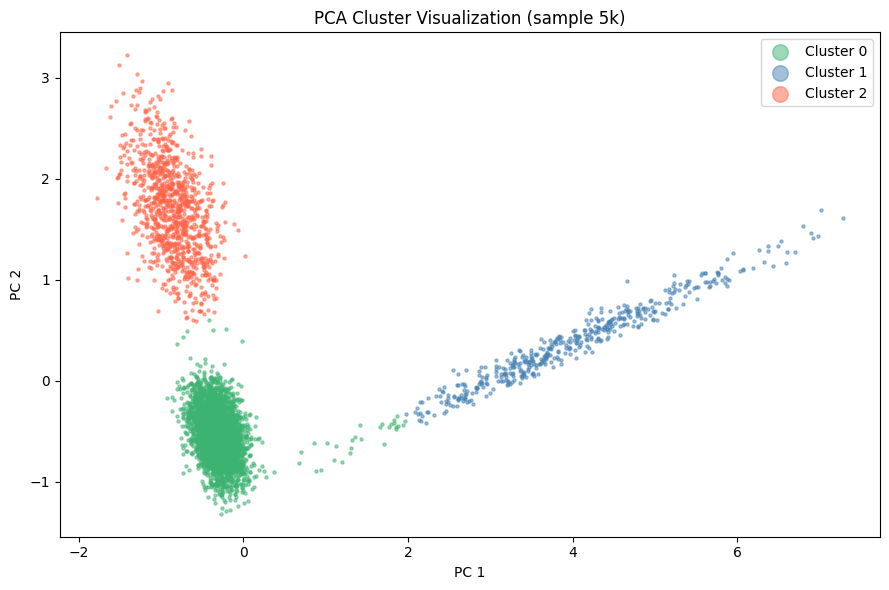

In [12]:
features = ["buffering_ms", "latency_ms", "watch_time_sec"]
X = df[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans: 3 clusters (smooth / moderate / severe)
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = km.fit_predict(X_scaled)

# PCA → 2D for visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(9, 6))
colors = ["mediumseagreen", "steelblue", "tomato"]
labels = {0: "Cluster 0", 1: "Cluster 1", 2: "Cluster 2"}

# Sample 5000 points so Colab doesn't slow down
sample = np.random.choice(len(X_2d), 5000, replace=False)
for c in range(3):
    mask = df["cluster"].values[sample] == c
    plt.scatter(X_2d[sample][mask, 0], X_2d[sample][mask, 1],
                s=5, alpha=0.5, color=colors[c], label=labels[c])

plt.title("PCA Cluster Visualization (sample 5k)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(markerscale=5)
plt.tight_layout()
plt.savefig("clusters.png", dpi=150)
plt.show()

Cluster Analysis

In [13]:
summary = df.groupby("cluster")[["buffering_ms", "latency_ms", "watch_time_sec"]].mean().round(1)
summary["watch_time_min"] = (summary["watch_time_sec"] / 60).round(1)
summary["count"] = df["cluster"].value_counts().sort_index()
summary["error_rate_%"] = (
    df[df["error_issue"] == "Playback Failure"]
    .groupby("cluster").size() / df.groupby("cluster").size() * 100
).round(2)

print(summary)

# Auto-label clusters by buffering level
def label_cluster(row):
    if row["buffering_ms"] < 500:
        return "✅ Smooth Streaming"
    elif row["buffering_ms"] < 2000:
        return "⚠️  Moderate Issues"
    else:
        return "🔴 Severe Issues"

summary["label"] = summary.apply(label_cluster, axis=1)
print("\nCluster Labels:")
print(summary[["buffering_ms", "latency_ms", "watch_time_min", "count", "label"]])

         buffering_ms  latency_ms  watch_time_sec  watch_time_min  count  \
cluster                                                                    
0               314.3        80.4          1800.4            30.0  35425   
1              4097.4       409.6           308.5             5.1   4703   
2               500.6        99.5          7234.9           120.6   9872   

         error_rate_%  
cluster                
0                6.00  
1               55.01  
2                9.29  

Cluster Labels:
         buffering_ms  latency_ms  watch_time_min  count                label
cluster                                                                      
0               314.3        80.4            30.0  35425   ✅ Smooth Streaming
1              4097.4       409.6             5.1   4703      🔴 Severe Issues
2               500.6        99.5           120.6   9872  ⚠️  Moderate Issues


Data Distribution

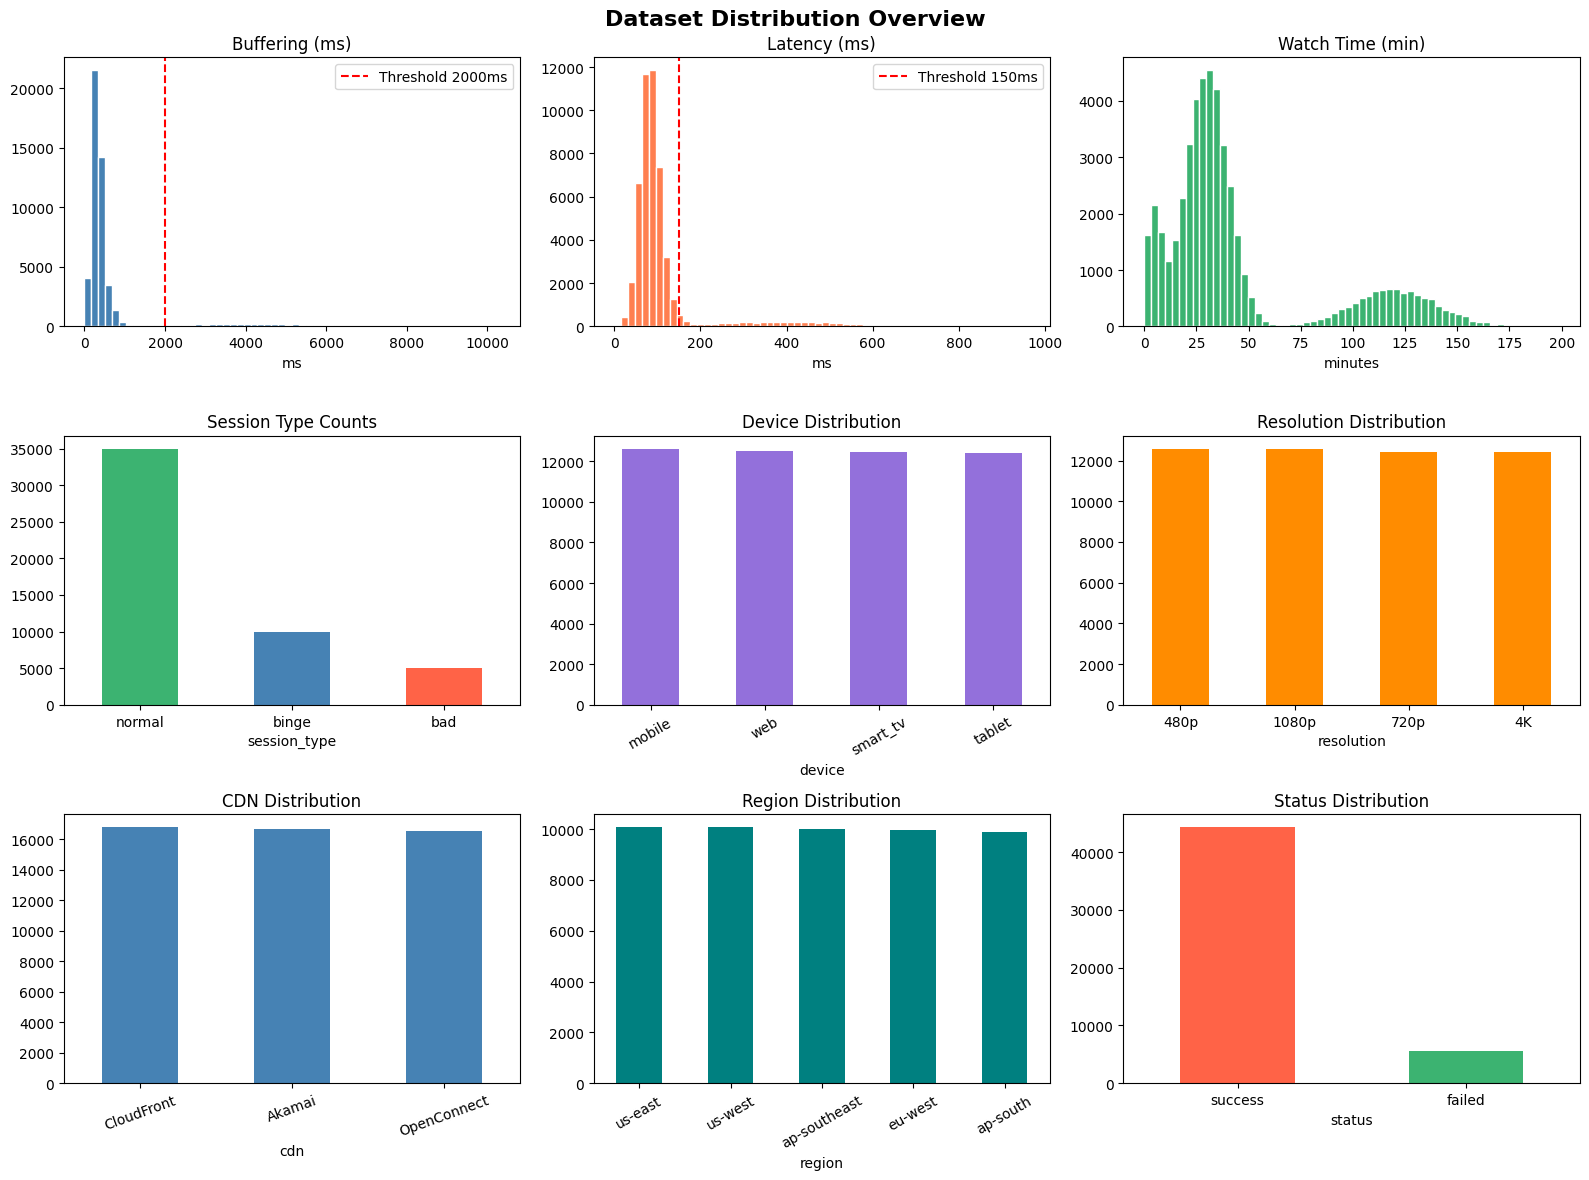

Distribution charts saved


In [14]:

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Dataset Distribution Overview", fontsize=16, fontweight="bold")

# 1. Buffering MS distribution
axes[0, 0].hist(df["buffering_ms"], bins=60, color="steelblue", edgecolor="white")
axes[0, 0].axvline(2000, color="red", linestyle="--", label="Threshold 2000ms")
axes[0, 0].set_title("Buffering (ms)")
axes[0, 0].set_xlabel("ms"); axes[0, 0].legend()

# 2. Latency MS distribution
axes[0, 1].hist(df["latency_ms"], bins=60, color="coral", edgecolor="white")
axes[0, 1].axvline(150, color="red", linestyle="--", label="Threshold 150ms")
axes[0, 1].set_title("Latency (ms)")
axes[0, 1].set_xlabel("ms"); axes[0, 1].legend()

# 3. Watch Time distribution
axes[0, 2].hist(df["watch_time_sec"] / 60, bins=60, color="mediumseagreen", edgecolor="white")
axes[0, 2].set_title("Watch Time (min)")
axes[0, 2].set_xlabel("minutes")

# 4. Session Type (your 3 profiles)
df["session_type"].value_counts().plot(kind="bar", ax=axes[1, 0],
    color=["mediumseagreen", "steelblue", "tomato"])
axes[1, 0].set_title("Session Type Counts")
axes[1, 0].tick_params(axis="x", rotation=0)

# 5. Device breakdown
df["device"].value_counts().plot(kind="bar", ax=axes[1, 1], color="mediumpurple")
axes[1, 1].set_title("Device Distribution")
axes[1, 1].tick_params(axis="x", rotation=30)

# 6. Resolution breakdown
df["resolution"].value_counts().plot(kind="bar", ax=axes[1, 2], color="darkorange")
axes[1, 2].set_title("Resolution Distribution")
axes[1, 2].tick_params(axis="x", rotation=0)

# 7. CDN distribution
df["cdn"].value_counts().plot(kind="bar", ax=axes[2, 0], color="steelblue")
axes[2, 0].set_title("CDN Distribution")
axes[2, 0].tick_params(axis="x", rotation=20)

# 8. Region distribution
df["region"].value_counts().plot(kind="bar", ax=axes[2, 1], color="teal")
axes[2, 1].set_title("Region Distribution")
axes[2, 1].tick_params(axis="x", rotation=30)

# 9. Status (success vs failed)
df["status"].value_counts().plot(kind="bar", ax=axes[2, 2],
    color=["tomato", "mediumseagreen"])
axes[2, 2].set_title("Status Distribution")
axes[2, 2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("data_distribution.png", dpi=150)
plt.show()
print("Distribution charts saved")